# Rote — experimental evidence

Rote is an authority layer that sits between an AI model's reasoning and any action that moves
money.

This notebook is where the numbers live. It is not a new experiment; it reads the result files
already stored in this repository and redraws them so they can be checked. Nothing here calls an
API, so it runs offline and needs no key.

### Where each number comes from

Results are tagged so you can tell them apart at a glance:

- *Measured* — read straight out of a stored result file.
- *Calculated here* — worked out in this notebook from the frozen baselines, so you can watch it
  happen.
- *Architecture* — a description of how the system is built. Not a measurement.
- *Limitation* — something this evidence does not show.

### Four numbers that get confused, and shouldn't

| | | |
|---|---|---|
| Automation coverage (match rate) | 34.8% | how much of the batch was automated |
| Model classification accuracy | 81.1% | how often the model picked the right category |
| Precision of automated actions | 100% | of the actions taken, how many were right |
| Wrong money movements | 0 | actions that moved money incorrectly |

Coverage is not accuracy. They answer different questions, and this notebook keeps them apart
throughout.

In [1]:
"""Setup: load the artifacts. No network, no credentials, no imports from the product."""

import collections
import json
import pathlib

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# the notebook lives in docs/experiments/, so the repository root is two levels up
ROOT = pathlib.Path.cwd()
while not (ROOT / "docs" / "baselines").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DOCS = ROOT / "docs"

# --- the validated palette this notebook draws with -------------------------
INK, MUTED, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e6e5e1"
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "figure.dpi": 110,
})


def read_jsonl(path):
    return [json.loads(x) for x in path.read_text(encoding="utf-8").splitlines() if x.strip()]


def baseline(name):
    """Rote's own decisions from a frozen baseline run log."""
    return [r for r in read_jsonl(DOCS / "baselines" / name / "runs.jsonl") if r.get("path") == "rote"]


V1 = {r["task_id"]: r for r in baseline("phase16_v1")}
V2 = {r["task_id"]: r for r in baseline("phase16_v2")}
GROQ = json.load((DOCS / "experiments/groq_500/summary.json").open(encoding="utf-8"))
LOCAL = json.load((DOCS / "experiments/real_llm/summary.json").open(encoding="utf-8"))
INJECTION = json.load((DOCS / "experiments/real_llm/injection.json").open(encoding="utf-8"))

G_LLM = GROQ["arms"]["groq:openai/gpt-oss-120b"]
G_DET = GROQ["arms"]["deterministic"]

print("Artifacts loaded — all local files, nothing fetched.\n")
for label, path in [
    ("V1 baseline",   DOCS / "baselines/phase16_v1/runs.jsonl"),
    ("V2 baseline",   DOCS / "baselines/phase16_v2/runs.jsonl"),
    ("Groq 500",      DOCS / "experiments/groq_500/summary.json"),
    ("Local sweep",   DOCS / "experiments/real_llm/summary.json"),
    ("Injection",     DOCS / "experiments/real_llm/injection.json"),
]:
    print(f"  {'OK ' if path.exists() else 'MISSING'} {label:14} {path.relative_to(ROOT)}")

print(f"\nV1 rows: {len(V1)}   V2 rows: {len(V2)}   Groq cases: {G_LLM['cases']}")

Artifacts loaded — all local files, nothing fetched.

  OK  V1 baseline    docs\baselines\phase16_v1\runs.jsonl
  OK  V2 baseline    docs\baselines\phase16_v2\runs.jsonl
  OK  Groq 500       docs\experiments\groq_500\summary.json
  OK  Local sweep    docs\experiments\real_llm\summary.json
  OK  Injection      docs\experiments\real_llm\injection.json

V1 rows: 500   V2 rows: 500   Groq cases: 500


---
## 1. The problem

*Architecture.*

A settlement line does not match, and the bank has paid less than we expected. That one fact fits
several different stories, and each story calls for a different action:

| If it is | The right thing to do is |
|---|---|
| a fee the gateway deducted | post a `fee` adjustment and mark the record matched |
| a customer who underpaid | post a `shortfall` adjustment and mark it partially settled |
| the same payment recorded twice | void the duplicate bank line first |
| a payment that landed after cut-off | post nothing, just match it |

From the numbers alone, several of these look identical. A system that picks the most likely story
and acts on it will sometimes post the wrong adjustment, close the record in the wrong state, and
leave nothing in the logs that looks unusual.

That is the failure worth designing against. Not the model crashing, but the model being confident
and wrong while its answer turns straight into money movement.

---
## 2. Why we added refusal

*Calculated here, from the frozen baselines in `docs/baselines/`.*

Our first version automated any case it had a plan for. The second version added one rule: if two
different procedures both fit the same evidence, stop and give the case to a person.

V1 — automate whenever a plan exists
   automated          500
   correct            440
   WRONG              60

V2 — refuse when the evidence is ambiguous
   automated          184   (coverage 36.8%)
   refused            316
   WRONG              0


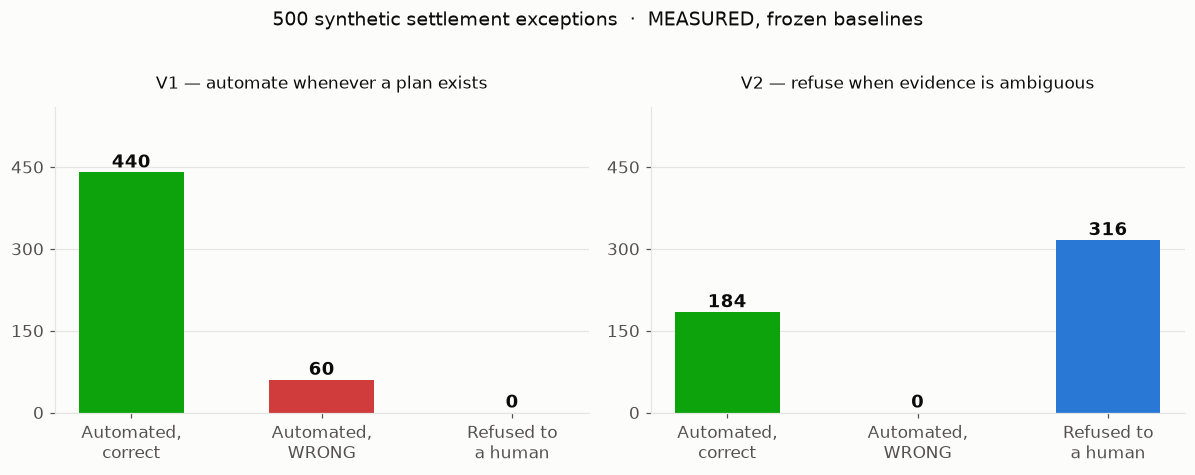

In [2]:
v1_wrong = {t for t, r in V1.items() if r["checker_verdict"] != "pass"}
v1_right = len(V1) - len(v1_wrong)
v2_auto = {t for t, r in V2.items() if r["route_reason"] == "plan_matched"}
v2_refused = set(V2) - v2_auto

print("V1 — automate whenever a plan exists")
print(f"   automated          {len(V1)}")
print(f"   correct            {v1_right}")
print(f"   WRONG              {len(v1_wrong)}")
print()
print("V2 — refuse when the evidence is ambiguous")
print(f"   automated          {len(v2_auto)}   (coverage {100*len(v2_auto)/len(V2):.1f}%)")
print(f"   refused            {len(v2_refused)}")
print(f"   WRONG              {sum(1 for t in v2_auto if V2[t]['checker_verdict'] != 'pass')}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, title, right, wrong, refused in [
    (ax1, "V1 — automate whenever a plan exists", v1_right, len(v1_wrong), 0),
    (ax2, "V2 — refuse when evidence is ambiguous", len(v2_auto), 0, len(v2_refused)),
]:
    labels, values, colors = ["Automated,\ncorrect"], [right], [GOOD]
    labels += ["Automated,\nWRONG"]; values += [wrong]; colors += [CRITICAL]
    labels += ["Refused to\na human"];  values += [refused]; colors += [BLUE]
    bars = ax.bar(labels, values, color=colors, width=0.55)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 9, str(value),
                ha="center", fontsize=12, fontweight="bold", color=INK)
    ax.set_title(title, fontsize=11, color=INK, pad=12)
    ax.set_ylim(0, 560)
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle("500 synthetic settlement exceptions  ·  MEASURED, frozen baselines",
             fontsize=12.5, color=INK, y=1.02)
plt.tight_layout()
plt.show()

The first version automated all 500 cases and got 60 of them wrong.

None of those 60 were crashes. The money cap allowed them. The guard approved them. Execution was
deterministic and the replay was byte-identical. They were wrong about what the evidence *meant*,
and checking shapes and ranges cannot catch that.

The second version automated 184 and got none of them wrong. It bought correctness by giving up
coverage, which is the trade this whole project is about.

In [3]:
saved = len(v1_wrong & v2_refused)
given_up = len(v2_refused) - saved

print("What refusing actually costs")
print(f"   refused cases V1 got WRONG (prevented)   {saved}")
print(f"   refused cases V1 got RIGHT (given up)    {given_up}")
print(f"   ratio                                    {given_up/saved:.1f} : 1")
print()
print(f"   V1 errors that survived into V2's automated set: "
      f"{len(v1_wrong & v2_auto)}   <- must be zero")

What refusing actually costs
   refused cases V1 got WRONG (prevented)   60
   refused cases V1 got RIGHT (given up)    256
   ratio                                    4.3 : 1

   V1 errors that survived into V2's automated set: 0   <- must be zero


*Calculated here.*

So refusing costs us roughly four correct automations for every wrong payment it prevents. That is
the real price of the safety property, and it is better to put it on the table ourselves than to
let someone work it out later.

The line underneath matters more: every one of the first version's 60 errors ends up inside the
refused set. None slipped through into the automated side.

---
## 3. What happened when we corrupted the evidence

*Measured, but with a caveat.* Unlike everything else here, this experiment did not leave behind a
machine-readable result file. The figures below are quoted from the written project record rather
than recomputed in this notebook. They are reported exactly as recorded.

Refusing on ambiguity deals with a wrong *label*. It says nothing about wrong *evidence*. So we
attacked the evidence instead, changing things like a bank amount by a single paisa.

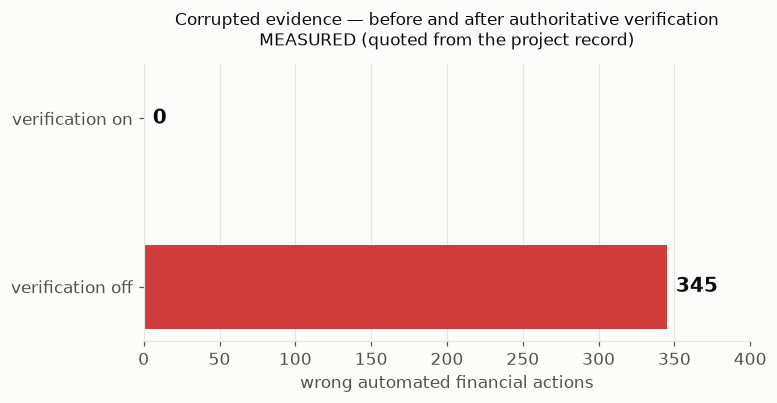

Detection rate with verification on: 345 of 345
False mismatches on clean data:      0%
Automation coverage:                 unchanged at 36.8%


In [4]:
# Quoted from the project record. Not recomputed - see the provenance note above.
CORRUPTION = {"verification off": 345, "verification on": 0}

fig, ax = plt.subplots(figsize=(7.2, 3.8))
bars = ax.barh(list(CORRUPTION), list(CORRUPTION.values()),
               color=[CRITICAL, GOOD], height=0.5)
for bar, value in zip(bars, CORRUPTION.values()):
    ax.text(value + 6, bar.get_y() + bar.get_height() / 2, str(value),
            va="center", fontsize=13, fontweight="bold", color=INK)
ax.set_xlim(0, 400)
ax.set_xlabel("wrong automated financial actions")
ax.set_title("Corrupted evidence — before and after authoritative verification\n"
             "MEASURED (quoted from the project record)", fontsize=11, color=INK, pad=12)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("Detection rate with verification on: 345 of 345")
print("False mismatches on clean data:      0%")
print("Automation coverage:                 unchanged at 36.8%")

345 wrong actions went straight through. Every layer approved them, which told us something
uncomfortable: Rote was checking whether the interpretation of the evidence made sense, but it had
no way to check whether the evidence itself was true.

The fix turned out to be sitting in the code already. Every plan reads the real settlement record
as its very first step, and that result was being fetched and then ignored. Reading the record and
the bank lines again through the Policy Gate, before any routing decision, caught all 345. Clean
cases were unaffected and coverage did not move.

---
## 4. The false alarm we refused to tune away

*Measured, quoted from the project record.*

The first version of that check flagged 89 perfectly good cases as mismatches. Every one was the
same category, and every one was about the same field.

The obvious move was to loosen a threshold until the number went away. We did not do that. We went
looking for the cause instead.

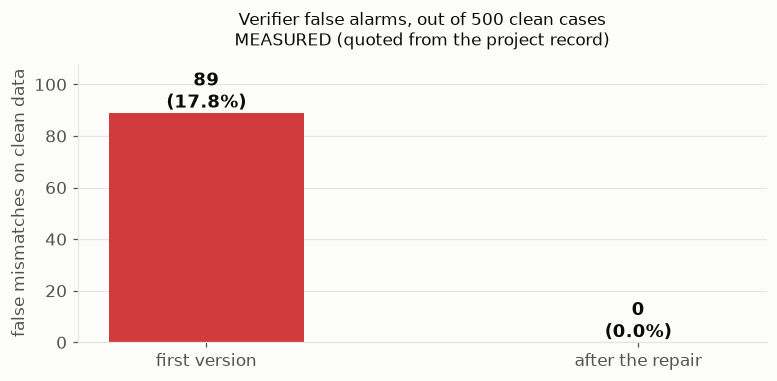

In [5]:
REPAIR = [("first version", 89, CRITICAL), ("after the repair", 0, GOOD)]

fig, ax = plt.subplots(figsize=(7.2, 3.6))
bars = ax.bar([r[0] for r in REPAIR], [r[1] for r in REPAIR],
              color=[r[2] for r in REPAIR], width=0.45)
for bar, (_, value, _) in zip(bars, REPAIR):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 2, f"{value}\n({value/500:.1%})",
            ha="center", fontsize=12, fontweight="bold", color=INK)
ax.set_ylim(0, 108)
ax.set_ylabel("false mismatches on clean data")
ax.set_title("Verifier false alarms, out of 500 clean cases\nMEASURED (quoted from the project record)",
             fontsize=11, color=INK, pad=12)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

The bug was ours. When the first lookup found nothing, a backup lookup ran, and the backup
sometimes returned only part of the answer while the code treated it as complete.

The repair was to use both lookups together and, when the result still cannot be confirmed, to say
so plainly rather than guess. False alarms went to zero.

This is the habit the rest of the project rests on. When a number looks wrong, find out why. Do not
adjust the number until it looks better.

---
## 5. The full 500-record run on Groq

*Measured. Source: `docs/experiments/groq_500/summary.json`.*

This is the whole batch in exactly the configuration that is deployed: Groq running
`openai/gpt-oss-120b`, evidence verification switched on, and nothing adjusted for the occasion.

In [6]:
cfg = GROQ["configuration"]
print("Configuration actually used")
for key in ("classifier", "provider", "model", "verify_evidence", "cases", "eval_seed"):
    print(f"   {key:18} {cfg[key]}")
print(f"   wall clock          {GROQ['wall_seconds_llm_arm']:.0f}s "
      f"({GROQ['rate_limit_waits']} rate-limit waits)")
print()

rows = [
    ("Records in batch",                 G_DET["cases"],                 G_LLM["cases"]),
    ("Automated (match rate)",           G_DET["automated"],             G_LLM["automated"]),
    ("Not automated (exceptions)",       G_DET["refused"],               G_LLM["refused"]),
    ("WRONG automated actions",          G_DET["wrong_automated_actions"], G_LLM["wrong_automated_actions"]),
    ("Plan lookups",                     G_DET["plan_lookups"],          G_LLM["plan_lookups"]),
    ("Compiled steps executed",          G_DET["compiled_steps_executed"], G_LLM["compiled_steps_executed"]),
    ("Provider failures",                G_DET["provider_failures"],     G_LLM["provider_failures"]),
    ("Untrusted blocks withheld",        G_DET["untrusted_withheld"],    G_LLM["untrusted_withheld"]),
    ("Ledger valid",                     G_DET["ledger_valid"],          G_LLM["ledger_valid"]),
]
print(f"{'metric':32} {'deterministic':>15} {'Groq':>15}")
print("-" * 64)
for label, a, b in rows:
    print(f"{label:32} {a!s:>15} {b!s:>15}")
print()
print(f"{'automation coverage':32} {G_DET['automation_coverage_per_mille']/10:>14.1f}% "
      f"{G_LLM['automation_coverage_per_mille']/10:>14.1f}%")
print(f"{'model classification accuracy':32} {G_DET['classification_accuracy_per_mille']/10:>14.1f}% "
      f"{G_LLM['classification_accuracy_per_mille']/10:>14.1f}%")

Configuration actually used
   classifier         llm
   provider           groq
   model              openai/gpt-oss-120b
   verify_evidence    True
   cases              500
   eval_seed          91
   wall clock          7062s (161 rate-limit waits)

metric                             deterministic            Groq
----------------------------------------------------------------
Records in batch                             500             500
Automated (match rate)                       184             174
Not automated (exceptions)                   316             326
WRONG automated actions                        0               0
Plan lookups                                 184             174
Compiled steps executed                      518             484
Provider failures                              0              20
Untrusted blocks withheld                      0            1000
Ledger valid                                True            True

automation coverage           

---
## 6. Accuracy and precision are not the same thing

*Measured.*

This distinction is the one most likely to be misread, so it gets a chart to itself.

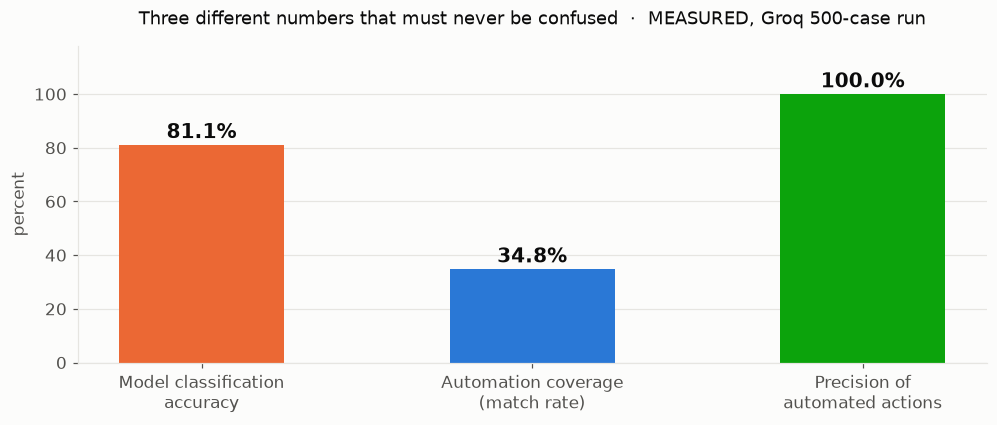

The model was right 81.1% of the time.
Rote automated 34.8% of the batch (174 of 500 records).
Of those 174 actions, 174 were correct -> precision 100%, with 0 wrong financial actions.


In [7]:
accuracy = G_LLM["classification_accuracy_per_mille"] / 10
coverage = G_LLM["automation_coverage_per_mille"] / 10
automated = G_LLM["automated"]
wrong = G_LLM["wrong_automated_actions"]
precision = 100.0 * (automated - wrong) / automated

fig, ax = plt.subplots(figsize=(9.2, 4.0))
labels = ["Model classification\naccuracy", "Automation coverage\n(match rate)",
          "Precision of\nautomated actions"]
values = [accuracy, coverage, precision]
colors = [ORANGE, BLUE, GOOD]
bars = ax.bar(labels, values, color=colors, width=0.5)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 2.5, f"{value:.1f}%",
            ha="center", fontsize=13, fontweight="bold", color=INK)
ax.set_ylim(0, 118)
ax.set_ylabel("percent")
ax.set_title("Three different numbers that must never be confused  ·  MEASURED, Groq 500-case run",
             fontsize=11.5, color=INK, pad=14)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"The model was right {accuracy:.1f}% of the time.")
print(f"Rote automated {coverage:.1f}% of the batch ({automated} of {G_LLM['cases']} records).")
print(f"Of those {automated} actions, {automated - wrong} were correct "
      f"-> precision {precision:.0f}%, with {wrong} wrong financial actions.")

Read the three bars from left to right.

The model was wrong about one case in five. Rote automated a little over a third of the batch,
which is coverage and not accuracy. And of the actions it actually took, every single one was
correct.

That gap is the point. The model does not have to be reliable. Rote only has to be right about when
to trust it. A wrong answer either contradicts the structured evidence or leaves two procedures
competing, and both of those end in a refusal.

---
## 7. The mistake the model kept making

*Measured. The confusion matrix from the Groq run.*

This is the result worth stopping on.

Where the model was RIGHT
   fee_mismatch->fee_mismatch                   119
   timing_cutoff->timing_cutoff                 106
   fx_rounding->fx_rounding                     68
   duplicate_entry->duplicate_entry             20
   partial_payment->partial_payment             4

Where the model was WRONG
   partial_payment->fee_mismatch                54
   duplicate_entry->timing_cutoff               20

Answers the classifier boundary rejected as unusable
   -> unknown (total)                           20


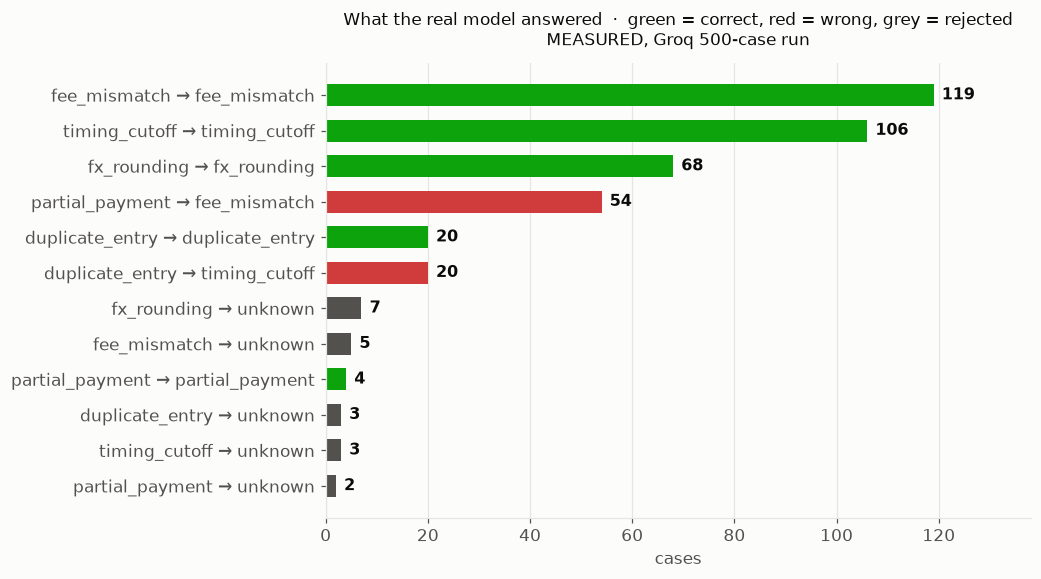

In [8]:
confusion = {k: v for k, v in G_LLM["confusion"].items() if v}
wrong_pairs = {k: v for k, v in confusion.items()
               if k.split("->")[0] != k.split("->")[1] and "unknown" not in k}
right_pairs = {k: v for k, v in confusion.items() if k.split("->")[0] == k.split("->")[1]}
unknown_pairs = {k: v for k, v in confusion.items() if "unknown" in k}

print("Where the model was RIGHT")
for k, v in sorted(right_pairs.items(), key=lambda kv: -kv[1]):
    print(f"   {k:44} {v}")
print("\nWhere the model was WRONG")
for k, v in sorted(wrong_pairs.items(), key=lambda kv: -kv[1]):
    print(f"   {k:44} {v}")
print("\nAnswers the classifier boundary rejected as unusable")
print(f"   {'-> unknown (total)':44} {sum(unknown_pairs.values())}")

ordered = sorted(confusion.items(), key=lambda kv: -kv[1])
labels = [k.replace("->", " → ") for k, _ in ordered]
values = [v for _, v in ordered]
colors = [GOOD if k.split("->")[0] == k.split("->")[1]
          else (MUTED if "unknown" in k else CRITICAL) for k, _ in ordered]

fig, ax = plt.subplots(figsize=(9.6, 5.4))
bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1], height=0.62)
for bar, value in zip(bars, values[::-1]):
    ax.text(value + 1.6, bar.get_y() + bar.get_height() / 2, str(value),
            va="center", fontsize=10.5, fontweight="bold", color=INK)
ax.set_xlim(0, 138)
ax.set_xlabel("cases")
ax.set_title("What the real model answered  ·  green = correct, red = wrong, grey = rejected\n"
             "MEASURED, Groq 500-case run", fontsize=11, color=INK, pad=12)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

The model's biggest single error was reading a partial payment as a fee mismatch, 54 times.

That is precisely the error that produced 60 wrong payments in our first version. A hosted,
frontier-class model, given the same queue, walked into the same trap we did.

Not one of those 54 became a financial action. Those cases have two procedures fitting the same
evidence, so Rote refuses them before it ever asks the registry for a plan.

The grey bars are worth a glance too. Twenty answers were not usable at all — a category name the
system does not recognise. Each one was converted to `unknown` with zero confidence at the
classifier boundary rather than being passed along.

---
## 8. The 326 cases it would not touch

*Measured.*

An exception list is only useful if you can see the actual cases. Every one of these is listed by
ID with its reason at `/exceptions` in the running application, and downloadable as CSV.

Exceptions: 326   (automated: 174)

    201  ambiguous_evidence           two procedures fit the same evidence
     89  evidence_unverifiable        evidence named a bank line the record could not confirm
     20  classifier_unavailable       the model provider could not be reached
     16  low_classifier_confidence    the model was not confident enough


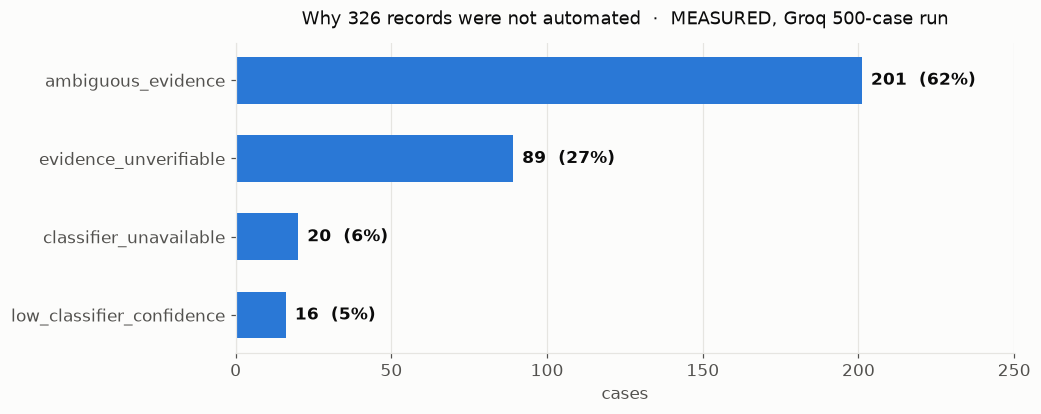


Plan lookups across the whole run: 174 (exactly the 174 automated cases)
Every one of the exceptions reached ZERO plan lookups and executed ZERO steps.


In [9]:
reasons = dict(sorted(G_LLM["route_reasons"].items(), key=lambda kv: -kv[1]))
exceptions = {k: v for k, v in reasons.items() if k != "plan_matched"}

PLAIN = {
    "ambiguous_evidence":        "two procedures fit the same evidence",
    "evidence_unverifiable":     "evidence named a bank line the record could not confirm",
    "classifier_unavailable":    "the model provider could not be reached",
    "low_classifier_confidence": "the model was not confident enough",
    "evidence_mismatch":         "evidence disagreed with the authoritative record",
}

total_exceptions = sum(exceptions.values())
print(f"Exceptions: {total_exceptions}   (automated: {reasons.get('plan_matched', 0)})\n")
for name, count in exceptions.items():
    print(f"   {count:4}  {name:28} {PLAIN.get(name, '')}")

fig, ax = plt.subplots(figsize=(9.6, 3.9))
names = list(exceptions)[::-1]
counts = [exceptions[n] for n in names]
bars = ax.barh(names, counts, color=BLUE, height=0.6)
for bar, value in zip(bars, counts):
    share = 100 * value / total_exceptions
    ax.text(value + 3, bar.get_y() + bar.get_height() / 2, f"{value}  ({share:.0f}%)",
            va="center", fontsize=11, fontweight="bold", color=INK)
ax.set_xlim(0, 250)
ax.set_xlabel("cases")
ax.set_title(f"Why {total_exceptions} records were not automated  ·  MEASURED, Groq 500-case run",
             fontsize=11.5, color=INK, pad=12)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"\nPlan lookups across the whole run: {G_LLM['plan_lookups']} "
      f"(exactly the {G_LLM['automated']} automated cases)")
print("Every one of the exceptions reached ZERO plan lookups and executed ZERO steps.")

Every refusal carries a named reason. Nothing is turned away as simply "unclear", and a person
picking up an ambiguous case is told which procedures were competing for it.

The number underneath the chart is the one to notice: plan lookups exactly equal the automated
count. A refused case never even asks for a procedure. The refusal happens before authority is
requested, not after it has been handed over.

---
## 9. What happens when the provider fails

*Measured.*

Twenty of the 500 cases could not reach the model at all. The demo API key allows roughly nine
calls a minute, and these ran out of retries.

In [10]:
failures = G_LLM["provider_failures"]
print(f"Provider failures: {failures} of {G_LLM['cases']} ({100*failures/G_LLM['cases']:.0f}%)")
print(f"Route reason recorded: classifier_unavailable  ({reasons.get('classifier_unavailable')})")
print()
print("What happened to those 20 cases:")
print("   plan lookups        0")
print("   steps executed      0")
print("   money moved         none")
print("   fallback to the deterministic classifier?   NO - deliberately not")
print()
print(f"Ledger still valid after the whole run: {G_LLM['ledger_valid']}")

Provider failures: 20 of 500 (4%)
Route reason recorded: classifier_unavailable  (20)

What happened to those 20 cases:
   plan lookups        0
   steps executed      0
   money moved         none
   fallback to the deterministic classifier?   NO - deliberately not

Ledger still valid after the whole run: True


*Architecture.*

When the provider fails, Rote refuses and says so. It does not quietly switch to the deterministic
classifier, because that would turn an outage into an invisible change in behaviour: the system
would look healthy while doing something other than what was configured.

A timeout, a rate limit, a malformed answer, an invalid confidence value and a missing credential
all end the same way. The case is refused, no plan is looked up, and nothing executes.

Failing closed is the design. Failing quietly would be the bug.

---
## 10. The audit trail

*Measured, plus a note on how it works.*

In [11]:
print("Ledger, Groq 500-case run")
print(f"   entries written     {G_LLM['ledger_entries']}")
print(f"   hash chain valid    {G_LLM['ledger_valid']}")
print()
print("Ledger, deterministic arm of the same run")
print(f"   entries written     {G_DET['ledger_entries']}")
print(f"   hash chain valid    {G_DET['ledger_valid']}")

Ledger, Groq 500-case run
   entries written     3011
   hash chain valid    True

Ledger, deterministic arm of the same run
   entries written     3079
   hash chain valid    True


Every decision is written to an append-only, hash-chained ledger, including every refusal.

Intent is recorded before the tool call and the outcome after it. If the process dies in between, a
person sees an unresolved entry rather than a silent double payment. Gate verdicts are recorded
too, including the ones that said no. Tampering with an earlier entry breaks the chain, and the
chain verifies.

Reading is audited as well. The evidence check goes through the same Policy Gate under its own
actor name, so even looking at the authoritative record leaves a trace.

---
## 11. Evidence from the deployed system

*Measured, from the end-to-end suite run against the live deployment over HTTP.*

| Case | What happened |
|---|---|
| Clean case | automated, one plan lookup, two steps, world changed |
| Ambiguous case | refused, zero lookups, zero steps, world unchanged |
| Corrupted evidence | refused, zero lookups, zero steps |
| Guard rejection | result thrown out before it became state, nothing committed |
| Gate rejection | amount over its per-action cap, refused |
| Same case twice | already resolved, world unchanged |
| Ledger | chain valid |

Timing, measured without the rate-limit pacing used during the batch run:

| Action | Time | Why |
|---|---|---|
| Automate a clean case | about 1 second | a live model call happens |
| Refuse corrupted evidence | about 40 ms | verification refuses before the model is called |

That 27-fold gap is itself evidence the model is genuinely in the loop. A hard-coded answer could
not produce it.

*Limitation.* The median latency stored in the result file measures the runner's rate-limit sleep,
not the provider, because the pause sits inside the timed section. It is reported here as invalid
rather than quoted as a model latency.

---
## 12. What this evidence does not show

*Limitations, all of it.*

The application reports `research_grade: false` about itself, and that never changes. It means the
system is running on a synthetic benchmark rather than validated production data. It is a statement
about scope, not about quality.

The financial world here is generated by a seeded generator written for this project. The safety
architecture is real; the world it acts on is not. These results demonstrate how the architecture
behaves on a controlled benchmark, and say nothing about real-world failure rates.

Everything was measured once, with one model, one provider, one seed and one benchmark. Hosted
models are also not reproducible: the same case can come back with different answers across runs
even at temperature zero. Every such answer was refused by the ambiguity rule, so the decision
stayed stable while the classification did not.

Twenty of the 500 cases hit the provider's rate limit. On a production key that number would be
lower, but it is what this deployment actually measured. The fallback agent is still a deterministic
stand-in; only the classifier is a real model.

The largest open question is coverage rather than safety. The 34.8% figure is a property of six
synthetic categories we wrote, only two of which are unambiguous. We have never shown that a real
exception queue contains a meaningful unambiguous slice, and if a real queue is mostly ambiguous
then Rote refuses nearly all of it. That is a question about data, and no amount of further building
answers it.

One more boundary worth naming: "authoritative" here means an independent *path* to the record, not
an independent *source*. The world and the evidence come from the same generator. A real deployment
would read a genuinely separate system of record.

Finally, the corruption and repair figures in sections 3 and 4 are quoted from the written record.
Those runs did not leave machine-readable files behind.

---
## What all of this adds up to

The claim, kept as narrow as the evidence allows:

> The language model does not need to be reliable for Rote to be useful. Rote checks the evidence
> independently, decides whether the model's answer is safe to act on, and refuses anything that
> does not meet its conditions.

What sits behind that sentence:

| | |
|---|---|
| The model was wrong about | one case in five |
| It repeated our worst historical error | 54 times |
| Wrong money movements | 0 |
| Precision of the actions taken | 100% |
| Exceptions returned with a reason | 326 |
| Plan lookups by refused cases | 0 |

A much weaker local model made the same point more bluntly. At 51% classification accuracy, wrong
on half the queue, it still produced zero wrong financial actions.

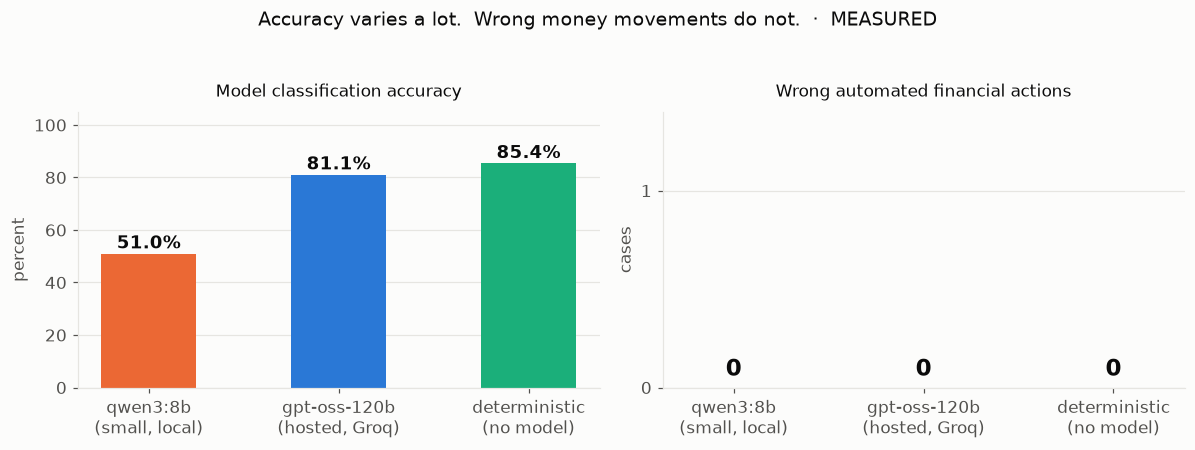

In [12]:
local = LOCAL["arms"]["llm:qwen3:8b"]
models = [
    ("qwen3:8b\n(small, local)", local["classification_accuracy_per_mille"] / 10,
     local["wrong_automated_actions"]),
    ("gpt-oss-120b\n(hosted, Groq)", G_LLM["classification_accuracy_per_mille"] / 10,
     G_LLM["wrong_automated_actions"]),
    ("deterministic\n(no model)", G_DET["classification_accuracy_per_mille"] / 10,
     G_DET["wrong_automated_actions"]),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.9))
names = [m[0] for m in models]

bars = ax1.bar(names, [m[1] for m in models], color=[ORANGE, BLUE, AQUA], width=0.5)
for bar, m in zip(bars, models):
    ax1.text(bar.get_x() + bar.get_width() / 2, m[1] + 2, f"{m[1]:.1f}%",
             ha="center", fontsize=11.5, fontweight="bold", color=INK)
ax1.set_ylim(0, 105); ax1.set_ylabel("percent")
ax1.set_title("Model classification accuracy", fontsize=11, color=INK, pad=10)
ax1.grid(axis="y", color=GRID, linewidth=0.8); ax1.set_axisbelow(True)

bars = ax2.bar(names, [m[2] for m in models], color=[GOOD, GOOD, GOOD], width=0.5)
for bar, m in zip(bars, models):
    ax2.text(bar.get_x() + bar.get_width() / 2, 0.06, str(m[2]),
             ha="center", fontsize=15, fontweight="bold", color=INK)
ax2.set_ylim(0, 1.4); ax2.set_ylabel("cases")
ax2.set_yticks([0, 1])   # a count, not a fraction
ax2.set_title("Wrong automated financial actions", fontsize=11, color=INK, pad=10)
ax2.grid(axis="y", color=GRID, linewidth=0.8); ax2.set_axisbelow(True)

fig.suptitle("Accuracy varies a lot.  Wrong money movements do not.  ·  MEASURED",
             fontsize=12.5, color=INK, y=1.04)
plt.tight_layout()
plt.show()

The left panel moves a great deal: 51%, then 81%, then 85%. The right panel does not move at all.

Change the model for a better one or a much worse one and the safety result stays where it is. That
is what it means for the architecture, rather than the model, to be the thing keeping money safe.

For the record, Rote is not claiming to be more accurate than the agent, to replace a rules engine,
to take people out of finance operations, or that any of these numbers carry over to a real payment
queue.

---
## Using this in the five-minute demo

| Order | Show | Roughly | The line to say |
|---|---|---|---|
| 1 | Section 7, the confusion matrix | 90 s | "The model made our worst historical mistake 54 times. Not one of them became a financial action." |
| 2 | Section 13, accuracy against wrong actions | 60 s | "Three models, wildly different accuracy. Zero wrong actions in every case." |
| 3 | Section 6, the three bars | 75 s | "81% accurate. 34.8% coverage, which is not accuracy. 100% precision on what we actually did." |
| 4 | Section 2, V1 against V2 | 60 s | "Our first version automated everything and was confidently wrong 60 times." |
| 5 | Section 12, limitations | 30 s | "Synthetic benchmark. The open question is coverage on a real queue." |

If time runs short, sections 7 and 13 carry the whole argument between them. Section 7 is the
story; section 13 shows it is not a fluke of one model.

Close on this:

> The model can make a decision. Rote decides whether that decision deserves authority.